# Histogram delta compression — wire bytes and throughput

Reads the output of `scripts/benchmarking/histogram_delta/run.sh` and draws the two figures:

1. **Bytes on the wire** per payload representation (rate-limited run — every variant ingests the same
   tuples, so a difference in bytes is a difference in representation).
2. **Ingest throughput** per representation (unthrottled Memory-source run, median of repetitions).

The two come from separate runs by necessity: equalising ingest is what makes the byte counts
comparable, and *not* equalising it is what makes the throughput meaningful.

Figures are drawn without a title or subtitle — they sit under a paper caption. What stays on the
canvas is what a caption cannot replace: axis labels, category labels and per-bar values.

In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### The two flat CSVs run.sh writes into the output root.
BYTES_CSV = "results_histogram_delta_bytes.csv"
THROUGHPUT_CSV = "results_histogram_delta_throughput.csv"

### Point RESULTS_DIR at the run you want to plot (the OUT_ROOT that run.sh printed), or leave it
### unset to auto-pick the most recent benchmark_run_* under the notebook, the repo root or /tmp.
### A candidate counts only if it holds the bytes CSV, so a half-written run is never picked.
def _autopick_run():
    here = Path.cwd()
    if (here / BYTES_CSV).exists():
        return here
    # plots/ -> histogram_delta/ -> benchmarking/ -> scripts/ -> repo root
    repo_root = (here / ".." / ".." / ".." / "..").resolve()
    candidates = []
    for base in (here, repo_root, Path("/tmp"), Path.home()):
        # benchmark_run_* is run.sh's default; bench-* is what we use on the remote, where output
        # must live outside the synced tree or rsync deletes it mid-run.
        candidates += glob.glob(str(base / "benchmark_run_*"))
        candidates += glob.glob(str(base / "bench-*"))
    candidates = [Path(c) for c in candidates if (Path(c) / BYTES_CSV).exists()]
    if not candidates:
        raise FileNotFoundError(
            f"No run with {BYTES_CSV} found. Produce one with\n"
            "    bash scripts/benchmarking/histogram_delta/run.sh\n"
            "or set RESULTS_DIR explicitly.")
    return max(candidates, key=lambda d: d.stat().st_mtime)


RESULTS_DIR = Path(os.environ["RESULTS_DIR"]) if os.environ.get("RESULTS_DIR") else _autopick_run()
OUT_DIR = Path(os.environ.get("FIGURE_DIR", RESULTS_DIR / "figures"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("results:", RESULTS_DIR.resolve())
print("figures:", OUT_DIR.resolve())

results: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots
figures: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures


## Styling

Colours come from seaborn's `colorblind` palette, the same source as the other notebooks under
`scripts/benchmarking/`. The assignment is deliberate: hue family = plan shape (blue = full synopsis,
orange = delta), and the lighter tone within each family = the zstd-compressed variant. That keeps
"which representation" and "is it compressed" readable as two separate visual questions.

Colour is never the only encoding: every bar carries its category as a tick label and its value as a
direct label, so the figures survive greyscale printing and any colour-vision deficiency.

Figure geometry follows the shared paper convention (`PAPER_RC`, `COL_W`/`FULL_W`, TrueType-embedded
PDF), so the output drops into a two-column layout at roughly 1:1.

In [2]:
### Shared "paper" look, kept in sync with the other benchmarking notebooks.
sns.set_theme(style="whitegrid", context="paper")

### Sized for a VLDB/SIGMOD/ICDE two-column camera-ready: figures go in at ~1:1, so the sizes here are
### the sizes on the page (body text is 9-10pt).
PAPER_RC = {
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "pdf.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
    "ps.fonttype": 42,
}

### Column widths in inches: single column and full width of a two-column layout.
COL_W, FULL_W = 3.3, 7.0

VARIANT_ORDER = ["split", "split_zstd", "delta", "delta_zstd"]
VARIANT_LABEL = {
    "split": "full synopsis",
    "split_zstd": "zstd",
    "delta": "delta",
    "delta_zstd": "delta + zstd",
}
BASELINE = "split"  # every comparison is against the uncompressed synopsis

### Colours from seaborn's colorblind palette, as everywhere else in scripts/benchmarking. The
### assignment is deliberate: hue family = plan shape (blue = full synopsis, orange = delta), lighter
### within the family = the zstd'd variant. So "which representation" and "is it compressed" stay
### readable as two separate visual questions.
_palette = sns.color_palette("colorblind")
VARIANT_COLOR = {
    "split": _palette[0],       # blue
    "split_zstd": _palette[9],  # light blue
    "delta": _palette[3],       # vermilion
    "delta_zstd": _palette[1],  # orange
}


def style_axis(ax, grid_axis="y"):
    """The per-axis finishing every figure in these notebooks shares."""
    ax.grid(True, axis=grid_axis, linestyle=":", linewidth=0.4, alpha=0.6)
    ax.grid(False, axis="x")  # vertical gridlines say nothing about nominal categories
    ax.tick_params(length=2, width=0.6)
    sns.despine(ax=ax)


def ordered(variants):
    present = set(variants)
    return [v for v in VARIANT_ORDER if v in present]


def bars(ax, variants, values, notes):
    """Vertical bars, linear axis, one direct label per bar.

    Linear on purpose: bar height must stay proportional to the value it encodes, so a log axis is not
    an option even though the values span a wide range.
    """
    xpos = range(len(variants))
    ax.bar(xpos, values, color=[VARIANT_COLOR[v] for v in variants], width=0.62, zorder=3)
    for x, v, note in zip(xpos, values, notes):
        ax.annotate(note, (x, v), fontsize=7, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points", linespacing=1.3)
    ax.set_xticks(list(xpos))
    ax.set_xticklabels([VARIANT_LABEL[v] for v in variants], fontsize=7)
    ax.set_ylim(0, max(values) * 1.22)  # headroom for the two-line labels
    style_axis(ax)

## Figure 1 — bytes on the wire

`total_bytes` is the root container's eth0 RX over the run, i.e. everything that actually crossed the
network to reach the store owner.

   variant    MB  vs split
     split 31.09      1.00
split_zstd 15.61      1.99
     delta  7.24      4.29
delta_zstd  3.67      8.48


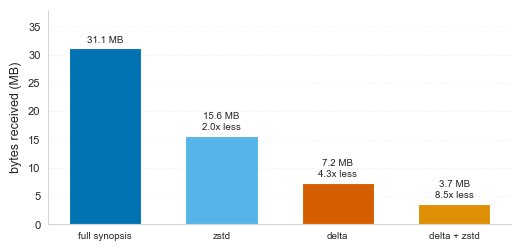

In [3]:
wire = pd.read_csv(RESULTS_DIR / BYTES_CSV)
wire = wire[wire["variant"].isin(VARIANT_ORDER)]
variants = ordered(wire["variant"])
mb = {v: wire.loc[wire["variant"] == v, "total_bytes"].iloc[0] / 1e6 for v in variants}
# None when VARIANTS excluded the baseline; the ratio line is then omitted.
base = mb.get(BASELINE)

notes = []
for v in variants:
    note = f"{mb[v]:,.1f} MB"
    if base and v != BASELINE:
        # Say which direction, so a variant above the baseline never reads as a saving.
        note += f"\n{base / mb[v]:.1f}x less" if mb[v] < base else f"\n{mb[v] / base:.1f}x more"
    notes.append(note)

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(0.95 * len(variants) + 1.5, 2.6))
    bars(ax, variants, [mb[v] for v in variants], notes)
    ax.set_ylabel("bytes received (MB)")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "wire_bytes.png", dpi=200, bbox_inches="tight")
print(pd.DataFrame({"variant": variants, "MB": [round(mb[v], 2) for v in variants],
                    "vs split": [round(base / mb[v], 2) if base else None for v in variants]}).to_string(index=False))

## Figure 2 — ingest throughput

`mean_tps` is the engine's own throughput listener, averaged over the active span (first to last
non-zero sample, interior zeros kept so stalls count). Grouped by local query id and taken over the
busiest stream, so a delta run's GEN ingest rate is not averaged with its RESOLVER's
one-blob-per-window rate.

Median across repetitions rather than mean: one run that hit a slow compile is an outlier and should
not drag the reported figure. The observed spread is printed alongside.

1 repetition(s): ['run1']
            median    min    max  spread %  vs split %
variant                                               
split        5.006  5.006  5.006       0.0         0.0
split_zstd   2.194  2.194  2.194       0.0       -56.0
delta        5.109  5.109  5.109       0.0         2.0
delta_zstd   4.521  4.521  4.521       0.0       -10.0


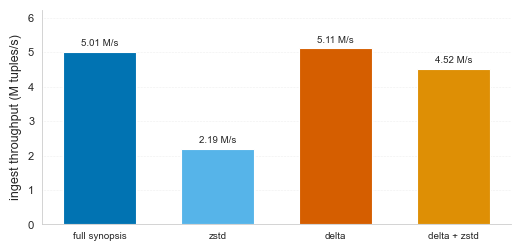

In [4]:
# ONLY=bytes leaves this file unwritten. Say what is missing and how to get it, rather than dying
# with a bare FileNotFoundError.
_tp_path = RESULTS_DIR / THROUGHPUT_CSV
if not _tp_path.exists():
    raise SystemExit(
        f"No {THROUGHPUT_CSV} under {RESULTS_DIR}.\n"
        "That half is produced by experiment 2/2; run it with\n"
        "    ONLY=throughput bash scripts/benchmarking/histogram_delta/run.sh")

tp = pd.read_csv(_tp_path)
tp = tp[tp["variant"].isin(VARIANT_ORDER)]
# run.sh merges the repetitions into this one file, tagging each with its `run`.
print(f"{tp['run'].nunique()} repetition(s):", sorted(tp["run"].unique()))

agg = tp.groupby("variant")["mean_tps"].agg(["median", "min", "max"]) / 1e6
variants = ordered(agg.index)
mtps = {v: agg.loc[v, "median"] for v in variants}
# None when VARIANTS excluded the baseline; the comparison line is then omitted.
base_tps = mtps.get(BASELINE)

# Value only. The relative comparison lives in the printed report below, not on the canvas: at a
# few percent between variants the annotation implied a precision the measurement does not have.
notes = [f"{mtps[v]:.2f} M/s" for v in variants]

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(0.95 * len(variants) + 1.5, 2.6))
    bars(ax, variants, [mtps[v] for v in variants], notes)
    ax.set_ylabel("throughput (M tuples/s)")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "throughput.png", dpi=200, bbox_inches="tight")

report = agg.loc[variants].copy()
report["spread %"] = ((report["max"] - report["min"]) / report["max"] * 100).round(1)
if base_tps:
    report["vs split %"] = ((report["median"] / base_tps - 1) * 100).round(0)
print(report.round(3).to_string())

## Table view

Every number behind both figures, so nothing is reachable only by reading a bar height.

In [5]:
table = (wire[["variant", "total_bytes"]]
         .assign(MB=lambda d: (d["total_bytes"] / 1e6).round(2))
         .drop(columns="total_bytes")
         .merge(agg["median"].rename("MTup_s").round(2), on="variant"))
if base:
    table["bytes_vs_split"] = (base / table["variant"].map(mb)).round(2)
if base_tps:
    table["tps_vs_split_%"] = ((table["variant"].map(mtps) / base_tps - 1) * 100).round(0)
table = table.set_index("variant").loc[variants]
display(table)
table.to_csv(OUT_DIR / "figures_table.csv")
print("wrote", OUT_DIR / "figures_table.csv")

,MB,MTup_s,bytes_vs_split,tps_vs_split_%
variant,,,,
split,31.09,5.01,1.00,0.0
split_zstd,15.61,2.19,1.99,-56.0
delta,7.24,5.11,4.29,2.0
delta_zstd,3.67,4.52,8.48,-10.0


wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/figures_table.csv
